In [88]:
import pandas as pd
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.feature_extraction import _stop_words
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
import re
import matplotlib.pyplot as plt

### Load Data

In [66]:
path = 'data/cds_vinyl_50k.csv'
data = pd.read_csv(path, sep=None, engine='python', encoding='utf-8', on_bad_lines='skip')

data.head()

,Unnamed: 0,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,0,5,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1.539920e+12,0,True
1,1,2,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1.668570e+12,0,True
2,2,5,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1.303010e+12,1,True
3,3,5,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1.412040e+12,0,True
4,4,4,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1.286730e+12,0,True


In [67]:
data.shape

(50000, 10)

In [68]:
data.describe()

,Unnamed: 0,rating,timestamp,helpful_vote
count,50000.000000,50000.000000,5.000000e+04,50000.000000
mean,24999.500000,4.499960,1.373586e+12,1.890020
std,14433.901067,1.004958,1.831194e+11,6.204271
min,0.000000,1.000000,8.937060e+11,0.000000
25%,12499.750000,4.000000,1.248210e+12,0.000000
50%,24999.500000,5.000000,1.416940e+12,0.000000
75%,37499.250000,5.000000,1.500780e+12,2.000000
max,49999.000000,5.000000,1.693160e+12,433.000000


In [69]:
data.isnull().sum()

Unnamed: 0            0
rating                0
title                 9
text                 11
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote          0
verified_purchase     0
dtype: int64

In [70]:
data = data.dropna()

In [71]:
data.isnull().sum()

Unnamed: 0           0
rating               0
title                0
text                 0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [72]:
data.dtypes

Unnamed: 0             int64
rating                 int64
title                 object
text                  object
asin                  object
parent_asin           object
user_id               object
timestamp            float64
helpful_vote           int64
verified_purchase       bool
dtype: object

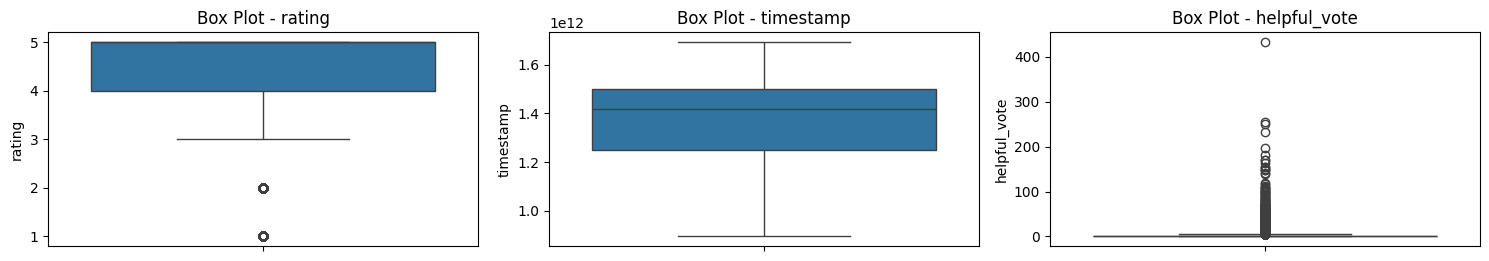

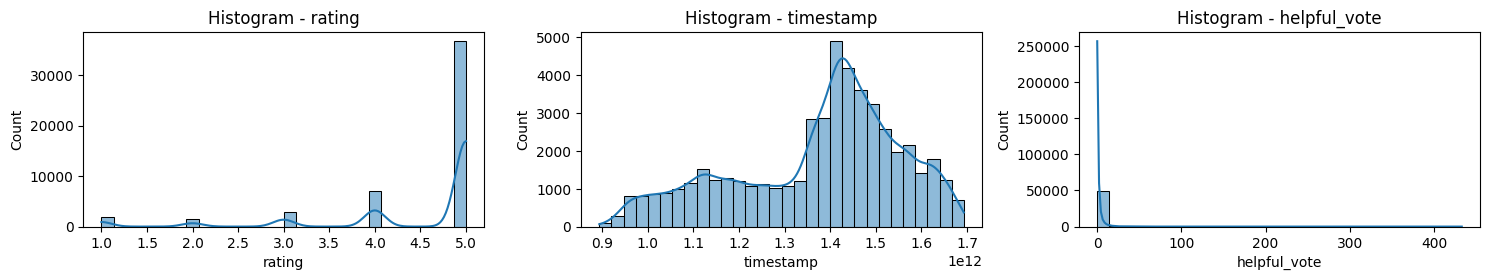

In [73]:
features = ['rating', 'timestamp', 'helpful_vote']

# Create box plots to detect outliers
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y = data[feature])
    plt.title(f"Box Plot - {feature}")

plt.tight_layout()
plt.show()

# Create histograms to check distributions
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data[feature], bins=30, kde=True)
    plt.title(f"Histogram - {feature}")

plt.tight_layout()
plt.show()

### Data Creation
#### We change the data to fit a binary classification task, where the target variable this the rating that is associated with the review. You try to predict the rating based on the content of the review. Define your target label.

In [74]:
data = data.assign(high_rating = np.where(data['rating'] >= 4, 1, 0))

##### What balance exists between positive and negative labels? Are there more negative or positive review?

In [75]:
  # Binary target from assignment
data["label"] = (data["rating"] >= 4).astype(int)  # 1 = positive, 0 = negative

  # Balance (put numbers in the report)
print(data["label"].value_counts())
print(data["label"].value_counts(normalize=True).mul(100).round(2).astype(str).add("%"))

label
1    43632
0     6352
Name: count, dtype: int64
label
1    87.29%
0    12.71%
Name: proportion, dtype: object


There are more positive than negative reviews, like the histograms already showed.

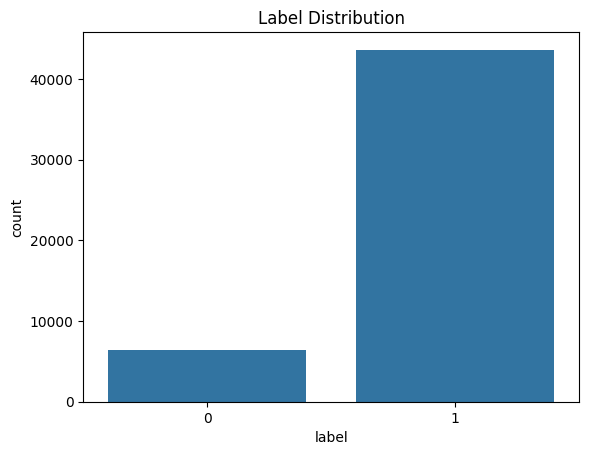

In [76]:
sns.countplot(data=data, x="label")
plt.title("Label Distribution")
plt.show()

#### 2. Preprocessing & Analysis

##### Tokenize and preprocess your dataset accordingly.

In [77]:
def clean_data(text):
    text = str(text)
    # Normalize whitespace and remove brackets
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\[.*?\]', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Lowercase and split
    words = text.lower().split()
    # Rejoin cleaned text
    cleaned_text = " ".join(words)
    return cleaned_text

data['cleaned_text'] = data['text'].apply(clean_data)

In [78]:
data['cleaned_text']

0                              this was a gift for someone
1        i am in love with the album of uria heepbr one...
2        not every artist in the music biz just wants t...
3                    excellent product thank you very much
4        this italian beauty has a wonderfulangelic ope...
                               ...                        
49995    if youre looking for the traditional lords pra...
49996    dj armin van buuren 5 ranked in 2002 24 years ...
49997    this cd is wayyy better than chronic a mustbuy...
49998    with the departure of peter gabriel tony banks...
49999    i was not so sure about this album until i lis...
Name: cleaned_text, Length: 49984, dtype: object

#### Provide descriptive statistics:
##### - Number of reviews
##### - Average words per review
##### - Number of unique words

In [79]:
len(data)

49984

In [80]:
def count_words(string):
  word_list = string.split(' ')
  return len(word_list)

all_words_count = 0
for row in data['cleaned_text']:
  word_count = count_words(row)
  all_words_count += word_count

round(all_words_count/len(data['cleaned_text']),2)

75.82

In [81]:
all_words = " ".join(data['cleaned_text']).lower().split()
len(set(all_words))

116996

There are 49984 reviews with an average 75,82 words per review and 116,996 unique words.

#### Show the 50 most common words in the corpus after preprocessing.

In [82]:
Counter(all_words).most_common(50)

[('the', 194229),
 ('and', 107729),
 ('of', 95039),
 ('a', 91695),
 ('to', 80606),
 ('is', 72000),
 ('i', 71263),
 ('this', 66034),
 ('it', 51106),
 ('in', 47661),
 ('that', 38625),
 ('on', 33326),
 ('for', 30988),
 ('with', 30883),
 ('album', 28567),
 ('you', 28244),
 ('but', 26454),
 ('as', 25646),
 ('was', 23913),
 ('are', 23688),
 ('cd', 21150),
 ('br', 21055),
 ('music', 20262),
 ('have', 19734),
 ('not', 19332),
 ('my', 18918),
 ('one', 18841),
 ('great', 18291),
 ('like', 17343),
 ('all', 16933),
 ('from', 16921),
 ('songs', 16371),
 ('its', 15977),
 ('be', 15040),
 ('his', 14832),
 ('song', 13458),
 ('love', 12707),
 ('good', 12699),
 ('so', 12664),
 ('if', 12573),
 ('by', 12367),
 ('just', 12034),
 ('has', 11893),
 ('they', 11841),
 ('at', 11431),
 ('more', 11334),
 ('an', 11285),
 ('very', 10847),
 ('some', 10705),
 ('me', 10673)]

#### 3.Bag-Of-Word Model

Remove stopwords. You can use the built-in dictionary from sklearn

In [83]:
stop_words = _stop_words.ENGLISH_STOP_WORDS

data['cleaned_text'] = data['cleaned_text'].apply(
    lambda text: " ".join(
        [word for word in text.split() if word.lower() not in stop_words]
    )
)

Show the 100 most common words after stopword removal

In [84]:
all_words_without_stop = " ".join(data['cleaned_text']).split()
most_common_words = [word for word, count in Counter(all_words_without_stop).most_common(100)]

Calculate mutual information for these 100 words with the target label and report the most informative ones.

In [89]:
X_text = data['cleaned_text']
y = data['high_rating']

vectorizer = CountVectorizer(vocabulary=most_common_words)
X_bow = vectorizer.fit_transform(X_text)

mi = mutual_info_classif(X_bow, y, discrete_features=True)

mi_series = pd.Series(mi, index=most_common_words)
mi_series = mi_series.sort_values(ascending=False)

print(mi_series.head(10))

bad       0.005831
like      0.004855
great     0.004569
just      0.004035
dont      0.004014
better    0.003615
doesnt    0.003259
songs     0.003038
love      0.002617
good      0.002616
dtype: float64
